# Clustering
You should build an end-to-end machine learning pipeline using a clustering model. In particular, you should do the following:
- Load the `customers` dataset using [Pandas](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html). You can find this dataset in the datasets folder.
- Conduct data exploration, data preprocessing, and feature engineering if necessary.
- Choose a few clustering algorithms, such as [k-means](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html), [hdbscan](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.HDBSCAN.html), and [agglomerative clustering](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html).
- Train and evaluate clustering models (i.e., the clustering algorithm and its hyperparameters) to find out the best-performing model using clustering evaluation metrics, such as [elbow method](https://www.scikit-yb.org/en/latest/api/cluster/elbow.html) and the [silhouette score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html).
- Check the documentation to identify the most important hyperparameters, attributes, and methods of the model. Use them in practice.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

import hdbscan

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [5]:
df = pd.read_csv("/content/customers.csv")

print(df.head())
print(df.info())
print(df.describe())

          ID  Sex  Marital status  Age  Education  Income  Occupation  \
0  100000001    0               0   67          2  124670           1   
1  100000002    1               1   22          1  150773           1   
2  100000003    0               0   49          1   89210           0   
3  100000004    0               0   45          1  171565           1   
4  100000005    0               0   53          1  149031           1   

   Settlement size  
0                2  
1                2  
2                0  
3                1  
4                1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ID               2000 non-null   int64
 1   Sex              2000 non-null   int64
 2   Marital status   2000 non-null   int64
 3   Age              2000 non-null   int64
 4   Education        2000 non-null   int64
 5   Income          

In [6]:
print("Dataset Shape:", df.shape)

# check missing values
print(df.isnull().sum())

# correlation matrix
print(df.corr())

Dataset Shape: (2000, 8)
ID                 0
Sex                0
Marital status     0
Age                0
Education          0
Income             0
Occupation         0
Settlement size    0
dtype: int64
                       ID       Sex  Marital status       Age  Education  \
ID               1.000000  0.328262        0.074403 -0.085246   0.012543   
Sex              0.328262  1.000000        0.566511 -0.182885   0.244838   
Marital status   0.074403  0.566511        1.000000 -0.213178   0.374017   
Age             -0.085246 -0.182885       -0.213178  1.000000   0.654605   
Education        0.012543  0.244838        0.374017  0.654605   1.000000   
Income          -0.303217 -0.195146       -0.073528  0.340610   0.233459   
Occupation      -0.291958 -0.202491       -0.029490  0.108388   0.064524   
Settlement size -0.378445 -0.300803       -0.097041  0.119751   0.034732   

                   Income  Occupation  Settlement size  
ID              -0.303217   -0.291958        -0.3784

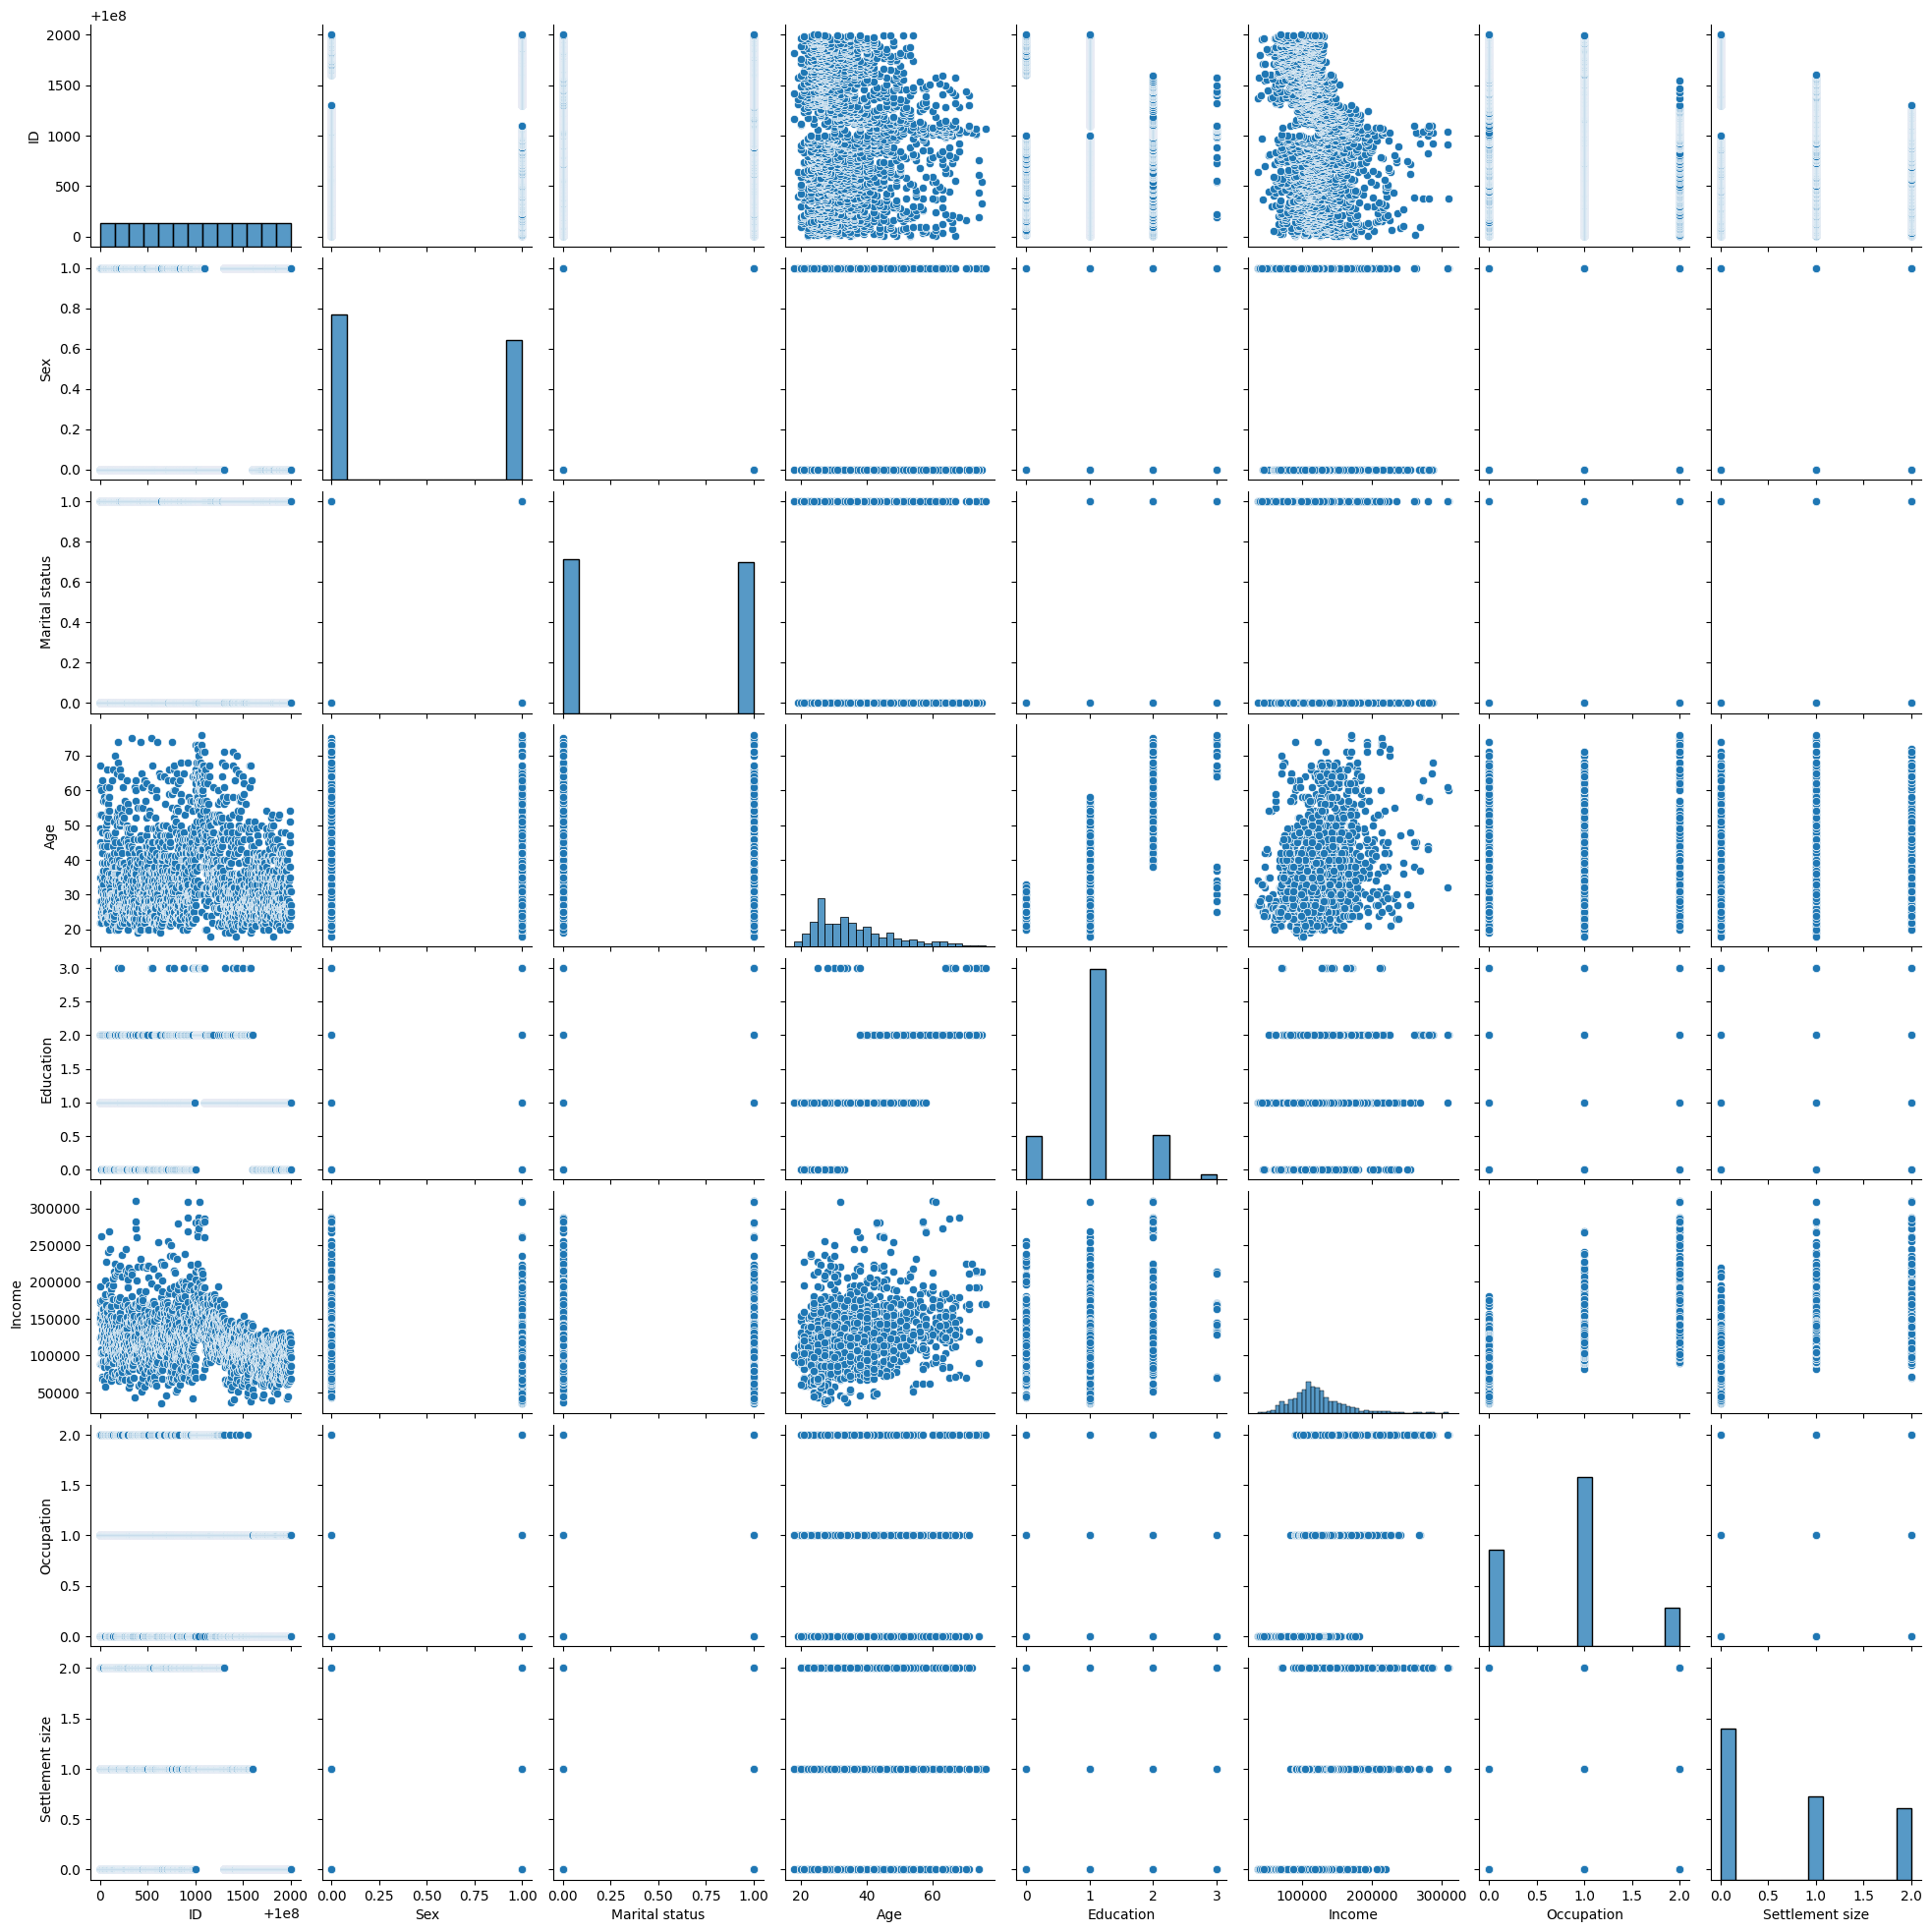

In [7]:
import seaborn as sns

sns.pairplot(df)
plt.show()

In [8]:
df = df.dropna()

In [9]:
df_numeric = df.select_dtypes(include=['int64','float64'])

In [10]:
scaler = StandardScaler()

X = scaler.fit_transform(df_numeric)

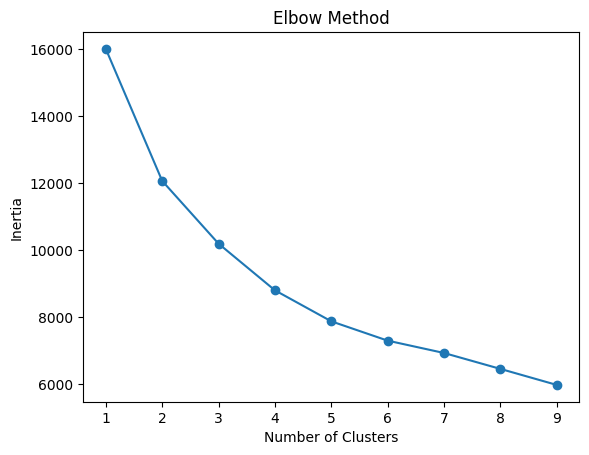

In [11]:
inertia = []

K = range(1,10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [12]:
kmeans = KMeans(n_clusters=3, random_state=42)

kmeans_labels = kmeans.fit_predict(X)

kmeans_score = silhouette_score(X, kmeans_labels)

print("KMeans Silhouette Score:", kmeans_score)

KMeans Silhouette Score: 0.24437057324500533


In [13]:
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')

agg_labels = agg.fit_predict(X)

agg_score = silhouette_score(X, agg_labels)

print("Agglomerative Silhouette Score:", agg_score)

Agglomerative Silhouette Score: 0.18063421720096534


In [14]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=10)

hdb_labels = clusterer.fit_predict(X)

hdb_score = silhouette_score(X, hdb_labels)

print("HDBSCAN Silhouette Score:", hdb_score)

HDBSCAN Silhouette Score: 0.2439690603421404


In [15]:
print("Model Comparison")

print("KMeans:", kmeans_score)
print("Agglomerative:", agg_score)
print("HDBSCAN:", hdb_score)

Model Comparison
KMeans: 0.24437057324500533
Agglomerative: 0.18063421720096534
HDBSCAN: 0.2439690603421404


In [16]:
df['Cluster'] = kmeans_labels

print(df.head())

          ID  Sex  Marital status  Age  Education  Income  Occupation  \
0  100000001    0               0   67          2  124670           1   
1  100000002    1               1   22          1  150773           1   
2  100000003    0               0   49          1   89210           0   
3  100000004    0               0   45          1  171565           1   
4  100000005    0               0   53          1  149031           1   

   Settlement size  Cluster  
0                2        2  
1                2        0  
2                0        0  
3                1        0  
4                1        0  


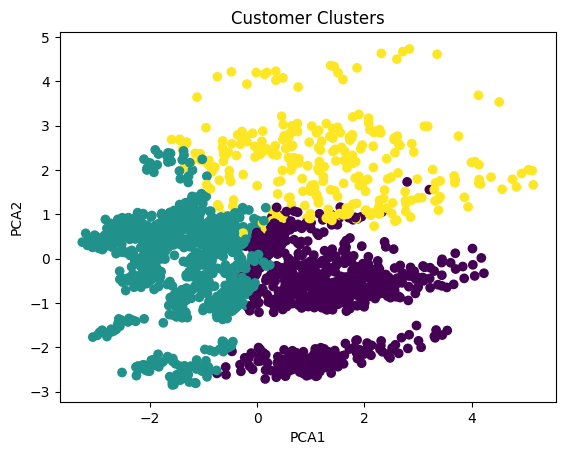

In [17]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels, cmap='viridis')

plt.title("Customer Clusters")
plt.xlabel("PCA1")
plt.ylabel("PCA2")

plt.show()